In [80]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# Random seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# Load data
# ============================================================

# data = pd.read_csv(
#     "../../../data/processed/model_df_next_mmse_blood.csv"
# )

data = pd.read_csv(
    "../../../data/processed/model_df_next_mmse3.csv"
)

print(data.shape)

df = data.copy()

Device: cuda
(5538, 58)


#### 缺失資料

In [81]:
# ============================================================
# Missing value summary
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_rate_pct": data.isna().mean() * 100
})

# 只保留有缺失值的欄位
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
]

# 缺失比例由大到小排序
missing_summary = missing_summary.sort_values(
    "missing_rate_pct",
    ascending=False
)

# 百分比四捨五入
missing_summary["missing_rate_pct"] = (
    missing_summary["missing_rate_pct"]
    .round(2)
)

print("\n================ Missing Value Summary ================\n")
print(missing_summary)

print("\n有缺失值的欄位數：", len(missing_summary))
print("總欄位數：", data.shape[1])
print("總資料筆數：", data.shape[0])


================ Missing Value Summary ================

                              missing_count  missing_rate_pct
fasting_glucose_blood_date             1154             20.84
fasting_glucose_gap_days               1154             20.84
fasting_glucose                        1154             20.84
vldl_gap_days                          1153             20.82
vldl                                   1153             20.82
vldl_blood_date                        1153             20.82
casi_date                              1099             19.84
casi_attention                         1099             19.84
casi_mental_manipulation               1099             19.84
casi_abstraction                       1099             19.84
casi_short_term_memory                 1099             19.84
casi_total                             1099             19.84
casi_language                          1099             19.84
casi_drawing                           1099             19.84
casi_verbal_

### 處理日期並排序 / 建立 visit gap days欄位，代表每次MMSE量測日期的時間差距

In [82]:
df["visit_date"] = pd.to_datetime(
    df["visit_date"],
    errors="coerce"
)

df = df.sort_values(
    ["patient_id", "visit_date"]
).reset_index(drop=True)

df["visit_gap_days"] = (
    df.groupby("patient_id")["visit_date"]
    .diff()
    .dt.days
)
#第一次 visit 沒有上一筆，所以填 0
df["visit_gap_days"] = (
    df["visit_gap_days"]
    .fillna(0)
)
#因為天數可能非常大，所以做：log (1+gap)
df["visit_gap_log"] = np.log1p(
    df["visit_gap_days"].clip(lower=0)
)

In [83]:
target_history_features = [
    "mmse"
]

cdr_features = [
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob",
]

casi_features = [
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total",
    "days_since_casi",
    "has_recent_casi",
]

blood_features = [
    "hdl",
    "vldl",
    "ldl",
    "total_cholesterol",
    "triglyceride",
    "fasting_glucose",
    "hba1c",
]

blood_gap_features = [
    "hdl_gap_days",
    "vldl_gap_days",
    "ldl_gap_days",
    "total_cholesterol_gap_days",
    "triglyceride_gap_days",
    "fasting_glucose_gap_days",
    "hba1c_gap_days",
]

#這些 血液日期gap 可能很大，所以也做 log transform
for col in blood_gap_features:

    new_col = col + "_log"

    df[new_col] = np.log1p(
        df[col].clip(lower=0)
    )

blood_gap_log_features = [
    col + "_log"
    for col in blood_gap_features
]

#其他 clinical features
clinical_features = [
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia",
    "apoe4_count",
    "apoe_missing",
    "gender"
]

#時間
time_features = [
    "visit_gap_log"
]

#全部
feature_cols = (
    target_history_features
    + cdr_features
    + casi_features
    + blood_features
    + blood_gap_log_features
    + clinical_features
    + time_features
)

print("Feature 數量:", len(feature_cols))

for col in feature_cols:
    print(col)

Feature 數量: 44
mmse
cdr_global
cdr_memory
cdr_orientation
cdr_judgment
cdr_community
cdr_home_hobbies
cdr_personal_care
cdr_sob
casi_mental_manipulation
casi_attention
casi_orientation
casi_long_term_memory
casi_short_term_memory
casi_abstraction
casi_drawing
casi_verbal_fluency
casi_language
casi_total
days_since_casi
has_recent_casi
hdl
vldl
ldl
total_cholesterol
triglyceride
fasting_glucose
hba1c
hdl_gap_days_log
vldl_gap_days_log
ldl_gap_days_log
total_cholesterol_gap_days_log
triglyceride_gap_days_log
fasting_glucose_gap_days_log
hba1c_gap_days_log
age_first_mmse
education
hypertension
diabetes
hyperlipidemia
apoe4_count
apoe_missing
gender
visit_gap_log


In [84]:
visit_counts = (
    df.groupby("patient_id")
    .size()
)

visit_counts.describe()

count    1297.000000
mean        4.269854
std         3.984301
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        24.000000
dtype: float64

### 建立df_model資料集，保留至少兩次mmse visit的病人

In [85]:
valid_patient_ids = (
    visit_counts[
        visit_counts >= 2
    ]
    .index
)

df_model = df[
    df["patient_id"].isin(valid_patient_ids)
].copy()

print(
    "至少兩次 visit 的 patient:",
    df_model["patient_id"].nunique()
)

至少兩次 visit 的 patient: 915


In [86]:
patient_group_counts = (
    df_model[
        ["patient_id", "bio_category"]
    ]
    .drop_duplicates()
    ["bio_category"]
    .value_counts()
)

print(patient_group_counts)

bio_category
non-AD    439
AD        414
CU         62
Name: count, dtype: int64


In [87]:
missing_summary = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_ratio": df_model.isnull().mean()
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0] \
    .sort_values("missing_count", ascending=False)

print(missing_summary)



                                missing_count  missing_ratio
casi_short_term_memory                    858       0.166408
casi_long_term_memory                     858       0.166408
casi_orientation                          858       0.166408
casi_attention                            858       0.166408
casi_mental_manipulation                  858       0.166408
casi_date                                 858       0.166408
casi_abstraction                          858       0.166408
casi_drawing                              858       0.166408
casi_language                             858       0.166408
casi_verbal_fluency                       858       0.166408
days_since_casi                           858       0.166408
casi_total                                858       0.166408
fasting_glucose                           831       0.161171
fasting_glucose_gap_days_log              831       0.161171
fasting_glucose_gap_days                  831       0.161171
fasting_glucose_blood_da

In [88]:
casi_missing_patient_count = (
    df_model.loc[df_model["casi_short_term_memory"].isnull(), "patient_id"]
    .nunique()
)

fasting_glucose_missing_patient_count = (
    df_model.loc[df_model["fasting_glucose"].isnull(), "patient_id"]
    .nunique()
)

print("casi_short_term_memory 缺失的 patient_id 數量：", casi_missing_patient_count)
print("fasting_glucose 缺失的 patient_id 數量：", fasting_glucose_missing_patient_count)

casi_short_term_memory 缺失的 patient_id 數量： 433
fasting_glucose 缺失的 patient_id 數量： 246


In [89]:
casi_all_missing_patient_count = (
    df_model.groupby("patient_id")["casi_short_term_memory"]
    .apply(lambda x: x.isnull().all())
    .sum()
)

fasting_glucose_all_missing_patient_count = (
    df_model.groupby("patient_id")["fasting_glucose"]
    .apply(lambda x: x.isnull().all())
    .sum()
)

print("所有紀錄的 casi_short_term_memory 都缺失的 patient_id 數量：", casi_all_missing_patient_count)
print("所有紀錄的 fasting_glucose 都缺失的 patient_id 數量：", fasting_glucose_all_missing_patient_count)

所有紀錄的 casi_short_term_memory 都缺失的 patient_id 數量： 139
所有紀錄的 fasting_glucose 都缺失的 patient_id 數量： 246


### 模型訓練

In [90]:
from sklearn.model_selection import train_test_split

GROUP = "CU"

group_df = df_model[
    df_model["bio_category"] == GROUP
].copy()

print(group_df.shape)

print(
    "Patients:",
    group_df["patient_id"].nunique()
)

#Patient-level train/validation/test split
patient_ids = (
    group_df["patient_id"]
    .drop_duplicates()
    .to_numpy()
)

train_ids, temp_ids = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=SEED
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=SEED
)

print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))
print("Test patients:", len(test_ids))

print(
    set(train_ids)
    & set(val_ids)
)

print(
    set(train_ids)
    & set(test_ids)
)

(207, 67)
Patients: 62
Train patients: 43
Val patients: 9
Test patients: 10
set()
set()


In [91]:
train_df = group_df[
    group_df["patient_id"].isin(train_ids)
].copy()

val_df = group_df[
    group_df["patient_id"].isin(val_ids)
].copy()

test_df = group_df[
    group_df["patient_id"].isin(test_ids)
].copy()

### 建立missing indicators

In [92]:
train_df = group_df[
    group_df["patient_id"].isin(train_ids)
].copy()

val_df = group_df[
    group_df["patient_id"].isin(val_ids)
].copy()

test_df = group_df[
    group_df["patient_id"].isin(test_ids)
].copy()

missing_indicator_cols = []

for col in feature_cols:

    if train_df[col].isna().any():

        indicator_col = col + "_missing"

        train_df[indicator_col] = (
            train_df[col].isna().astype(int)
        )

        val_df[indicator_col] = (
            val_df[col].isna().astype(int)
        )

        test_df[indicator_col] = (
            test_df[col].isna().astype(int)
        )

        missing_indicator_cols.append(
            indicator_col
        )

In [93]:
print(
    "Missing indicators:",
    len(missing_indicator_cols)
)

Missing indicators: 25


### 缺值處理 (中位數填補)

In [94]:
imputer = SimpleImputer(
    strategy="median"
)

imputer.fit(
    train_df[feature_cols]
)

train_df[feature_cols] = imputer.transform(
    train_df[feature_cols]
)

val_df[feature_cols] = imputer.transform(
    val_df[feature_cols]
)

test_df[feature_cols] = imputer.transform(
    test_df[feature_cols]
)

In [95]:
final_feature_cols = (
    feature_cols
    + missing_indicator_cols
)

### StandardScaler LSTM 不適合：尺度差很多的輸入。所以做 standardization

In [96]:
scaler = StandardScaler()
# missing indicator 不需要 scaling。所以只 scale 原始數值：
scaler.fit(
    train_df[feature_cols]
)

train_df[feature_cols] = scaler.transform(
    train_df[feature_cols]
)

val_df[feature_cols] = scaler.transform(
    val_df[feature_cols]
)

test_df[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

### 建立sequence

In [97]:
def create_sequences(
    data,
    feature_cols
):

    sequences = []
    targets = []
    patient_ids = []

    for patient_id, patient_df in data.groupby(
        "patient_id"
    ):

        patient_df = patient_df.sort_values(
            "visit_date"
        )

        # 至少需要兩筆
        if len(patient_df) < 2:
            continue

        # 過去所有 visit
        history = patient_df.iloc[:-1]

        # 最後一次 visit
        last_visit = patient_df.iloc[-1]

        X = history[
            feature_cols
        ].values.astype(
            np.float32
        )

        y = np.float32(
            last_visit["mmse"]
        )

        sequences.append(X)
        targets.append(y)
        patient_ids.append(patient_id)

    return (
        sequences,
        np.array(targets),
        patient_ids
    )

In [98]:
X_train, y_train, train_patient_ids = (
    create_sequences(
        train_df,
        final_feature_cols
    )
)

X_val, y_val, val_patient_ids = (
    create_sequences(
        val_df,
        final_feature_cols
    )
)

X_test, y_test, test_patient_ids = (
    create_sequences(
        test_df,
        final_feature_cols
    )
)

In [99]:
print(len(X_train))
print(len(X_val))
print(len(X_test))

43
9
10


### 建立 PyTorch Dataset

In [100]:
class MMSESequenceDataset(Dataset):

    def __init__(
        self,
        sequences,
        targets
    ):

        self.sequences = sequences
        self.targets = targets

    def __len__(self):

        return len(
            self.sequences
        )

    def __getitem__(
        self,
        idx
    ):

        sequence = torch.tensor(
            self.sequences[idx],
            dtype=torch.float32
        )

        target = torch.tensor(
            self.targets[idx],
            dtype=torch.float32
        )

        return sequence, target

In [101]:
train_dataset = MMSESequenceDataset(
    X_train,
    y_train
)

val_dataset = MMSESequenceDataset(
    X_val,
    y_val
)

test_dataset = MMSESequenceDataset(
    X_test,
    y_test
)

In [102]:
#處理 variable-length sequence 因為patient visit長度不盡相同，需要padding至相同長度的sequencce

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    sequences, targets = zip(*batch)

    lengths = torch.tensor(
        [
            len(seq)
            for seq in sequences
        ],
        dtype=torch.long
    )

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )

    targets = torch.stack(
        targets
    )

    return (
        padded_sequences,
        lengths,
        targets
    )

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

for X, lengths, y in train_loader:

    print("X:", X.shape)
    print("lengths:", lengths.shape)
    print("y:", y.shape)

    break

X: torch.Size([16, 9, 69])
lengths: torch.Size([16])
y: torch.Size([16])


### 建立 LSTM-NARX model

In [103]:
from torch.nn.utils.rnn import pack_padded_sequence

class LSTMNARX(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=32,
        num_layers=1,
        dropout=0.2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(
        self,
        x,
        lengths
    ):

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (
            hidden,
            cell
        ) = self.lstm(
            packed
        )

        # 最後一層 LSTM hidden state
        final_hidden = hidden[-1]

        final_hidden = self.dropout(
            final_hidden
        )

        output = self.fc(
            final_hidden
        )

        return output.squeeze(1)

In [104]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

INPUT_SIZE = len(
    final_feature_cols
)

print(INPUT_SIZE)

model = LSTMNARX(
    input_size=INPUT_SIZE,
    hidden_size=32,
    num_layers=1,
    dropout=0.2
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

cuda
69


In [105]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0

    for X, lengths, y in loader:

        X = X.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        predictions = model(
            X,
            lengths
        )

        loss = criterion(
            predictions,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * X.size(0)
        )

    return (
        total_loss
        / len(loader.dataset)
    )

def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for X, lengths, y in loader:

            X = X.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            predictions = model(
                X,
                lengths
            )

            loss = criterion(
                predictions,
                y
            )

            total_loss += (
                loss.item()
                * X.size(0)
            )

    return (
        total_loss
        / len(loader.dataset)
    )

In [106]:
EPOCHS = 300
PATIENCE = 300

best_val_loss = float("inf")
patience_counter = 0

best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_model_state = {
            k: v.cpu().clone()
            for k, v
            in model.state_dict().items()
        }

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "Early stopping!"
            )

            break

model.load_state_dict(
    best_model_state
)

model = model.to(
    DEVICE
)

Epoch 001 | Train Loss: 1.0123 | Val Loss: 1.6393
Epoch 002 | Train Loss: 0.9983 | Val Loss: 1.6256
Epoch 003 | Train Loss: 0.9790 | Val Loss: 1.6073
Epoch 004 | Train Loss: 0.9179 | Val Loss: 1.5920
Epoch 005 | Train Loss: 0.8626 | Val Loss: 1.5727
Epoch 006 | Train Loss: 0.8934 | Val Loss: 1.5564
Epoch 007 | Train Loss: 0.8355 | Val Loss: 1.5440
Epoch 008 | Train Loss: 0.7985 | Val Loss: 1.5273
Epoch 009 | Train Loss: 0.7496 | Val Loss: 1.5122
Epoch 010 | Train Loss: 0.7226 | Val Loss: 1.4989
Epoch 011 | Train Loss: 0.7177 | Val Loss: 1.4899
Epoch 012 | Train Loss: 0.6790 | Val Loss: 1.4817
Epoch 013 | Train Loss: 0.6424 | Val Loss: 1.4698
Epoch 014 | Train Loss: 0.6331 | Val Loss: 1.4582
Epoch 015 | Train Loss: 0.5998 | Val Loss: 1.4491
Epoch 016 | Train Loss: 0.5656 | Val Loss: 1.4428
Epoch 017 | Train Loss: 0.5456 | Val Loss: 1.4382
Epoch 018 | Train Loss: 0.4979 | Val Loss: 1.4318
Epoch 019 | Train Loss: 0.5374 | Val Loss: 1.4258
Epoch 020 | Train Loss: 0.4565 | Val Loss: 1.4201


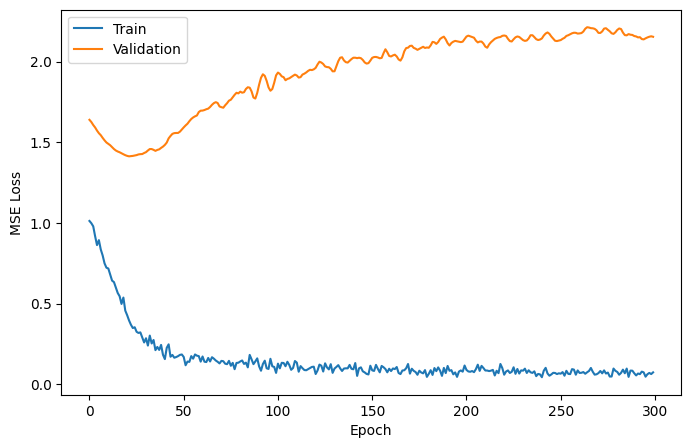

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.show()

### test prediction

In [108]:
def predict(
    model,
    loader,
    device
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X, lengths, y in loader:

            X = X.to(device)
            lengths = lengths.to(device)

            pred = model(
                X,
                lengths
            )

            predictions.extend(
                pred.cpu().numpy()
            )

            targets.extend(
                y.numpy()
            )

    return (
        np.array(predictions),
        np.array(targets)
    )

In [109]:
y_pred, y_true = predict(
    model,
    test_loader,
    DEVICE
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

print(
    f"MAE : {mae:.3f}"
)

print(
    f"RMSE: {rmse:.3f}"
)

print(
    f"R²  : {r2:.3f}"
)

MAE : 0.376
RMSE: 0.518
R²  : 0.076


### baseline

In [110]:
def last_mmse_baseline(
    data,
    patient_ids
):

    predictions = []
    targets = []

    for patient_id in patient_ids:

        patient_df = (
            data[
                data["patient_id"]
                == patient_id
            ]
            .sort_values(
                "visit_date"
            )
        )

        if len(patient_df) < 2:
            continue

        previous_mmse = (
            patient_df.iloc[-2]["mmse"]
        )

        target_mmse = (
            patient_df.iloc[-1]["mmse"]
        )

        predictions.append(
            previous_mmse
        )

        targets.append(
            target_mmse
        )

    return (
        np.array(predictions),
        np.array(targets)
    )

In [111]:
baseline_pred, baseline_true = (
    last_mmse_baseline(
        test_df,
        test_ids
    )
)

baseline_mae = mean_absolute_error(
    baseline_true,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_true,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    baseline_true,
    baseline_pred
)

print("Last-MMSE baseline")

print(
    f"MAE : {baseline_mae:.3f}"
)

print(
    f"RMSE: {baseline_rmse:.3f}"
)

print(
    f"R²  : {baseline_r2:.3f}"
)

Last-MMSE baseline
MAE : 0.626
RMSE: 0.852
R²  : -1.500
